# **UTS Model**

End-to-end regression pipeline for AISI 4140 heat-treatment data: baseline model
selection, feature engineering, model evaluation, hyperparameter tuning, and a
final production-ready pipeline.

**To model a different target property** (e.g. yield strength, tensile strength
instead of hardness), change only `TARGET_COLUMN` in the Configuration cell below.
Every section downstream reads the target from that one variable, so no other
code needs to change as long as the new column exists in the same dataset.

## Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Configuration

This is the only cell you need to edit to retarget the whole notebook at a
different property. `TARGET_COLUMN` is used everywhere a target is needed —
in the baseline model, the feature-engineering experiments, hyperparameter
tuning, and the final saved pipeline — so switching it here is enough.

In [3]:
# Paths
DATA_PATH = "/content/drive/MyDrive/Heat_Treatment_Dashboard/data/aisi_4140_heat_treatment_dataset.csv"
RESULTS_PATH = "/content/drive/MyDrive/Heat_Treatment_Dashboard/results"
MODELS_PATH = "/content/drive/MyDrive/Heat_Treatment_Dashboard/models"

# --- Change this to model a different Y ---
TARGET_COLUMN = "UTS_MPa"

# Input features (kept the same regardless of target)
BASE_FEATURE_COLUMNS = [
    "austenitizing_temp_C",
    "section_thickness_mm",
    "quench_medium",
    "tempering_temp_C",
    "tempering_time_hr"
]

NUMERICAL_FEATURES = [
    "austenitizing_temp_C",
    "section_thickness_mm",
    "tempering_temp_C",
    "tempering_time_hr"
]

CATEGORICAL_FEATURES = [
    "quench_medium"
]

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

In [4]:
df = pd.read_csv(DATA_PATH)
df.head()

,austenitizing_temp_C,section_thickness_mm,quench_medium,tempering_temp_C,tempering_time_hr,hardness_HRC,UTS_MPa,YS_MPa,elongation_pct,reduction_of_area_pct,source
0,845.0,25.0,oil,815.0,1.0,13.0,655.0,415.0,25.7,56.9,literature_anchor_annealed
1,845.0,25.0,oil,316.0,1.0,47.0,1551.0,1372.6,12.0,42.0,literature_anchor
2,845.0,25.0,oil,538.0,1.0,26.0,896.0,672.0,18.0,55.0,literature_anchor
3,851.7,50.0,oil,384.7,4.0,38.8,1212.1,1004.6,17.1,44.3,physics_model
4,834.4,100.0,air,401.7,4.0,37.4,1177.4,952.6,19.3,44.9,physics_model


### Reusable helper functions

These consolidate logic that was previously repeated across cells: building a
preprocessing `ColumnTransformer`, scoring predictions, running cross-validation,
and computing the engineered tempering features.

In [5]:
def build_preprocessor(numerical_features, categorical_features):
    """Standard scale numeric features, one-hot encode categorical features."""

    numerical_transformer = Pipeline(steps=[("scaler", StandardScaler())])
    categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

    return ColumnTransformer(
        transformers=[
            ("num", numerical_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )


def evaluate_predictions(y_true, y_pred):
    """Return (MAE, RMSE, R2) for a set of predictions."""

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


def run_cross_validation(pipeline, X, y, cv):
    """5-fold (or however many `cv` splits into) CV, returning mean +/- std for MAE, RMSE, R2."""

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=False
    )

    return {
        "MAE": -scores["test_MAE"].mean(),
        "MAE_STD": scores["test_MAE"].std(),
        "RMSE": -scores["test_RMSE"].mean(),
        "RMSE_STD": scores["test_RMSE"].std(),
        "R2": scores["test_R2"].mean(),
        "R2_STD": scores["test_R2"].std()
    }


def add_engineered_features(data, C=20):
    """Add the temp x time interaction and Hollomon-Jaffe tempering parameter."""

    data = data.copy()

    data["tempering_temp_time"] = (
        data["tempering_temp_C"] * data["tempering_time_hr"]
    )

    data["tempering_parameter"] = (
        (data["tempering_temp_C"] + 273.15)
        * (C + np.log10(data["tempering_time_hr"]))
    )

    return data

In [6]:
cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

## Baseline Model Selection

We compare three baseline regressors — Linear Regression, Random Forest, and Gradient Boosting — on the raw input features, before any feature engineering.

In [7]:
X = df[BASE_FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(TARGET_COLUMN)

Features:
['austenitizing_temp_C', 'section_thickness_mm', 'quench_medium', 'tempering_temp_C', 'tempering_time_hr']

Target:
UTS_MPa


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (880, 5)
X_test : (220, 5)
y_train: (880,)
y_test : (220,)


In [9]:
preprocessor = build_preprocessor(NUMERICAL_FEATURES, CATEGORICAL_FEATURES)

In [10]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

In [11]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [12]:
for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [13]:
predictions = {}

for name, pipeline in pipelines.items():

    predictions[name] = pipeline.predict(X_test)

In [14]:
results = []

for name in pipelines:

    mae, rmse, r2 = evaluate_predictions(
        y_test,
        predictions[name]
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,66.801206,89.043583,0.932801
1,Random Forest,35.236739,46.295600,0.981835
2,Gradient Boosting,34.504017,44.638355,0.983112


In [15]:
results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
2,Gradient Boosting,34.504017,44.638355,0.983112
1,Random Forest,35.236739,46.295600,0.981835
0,Linear Regression,66.801206,89.043583,0.932801


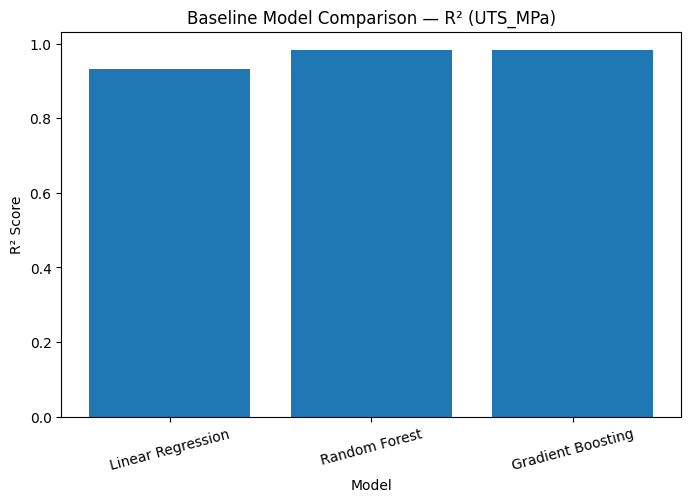

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title(f"Baseline Model Comparison — R² ({TARGET_COLUMN})")

plt.xticks(rotation=15)

plt.show()

In [17]:
best_model_name = results_df.loc[
    results_df["R2"].idxmax(),
    "Model"
]

print("Best baseline model:", best_model_name)

Best baseline model: Gradient Boosting


In [18]:
y_pred_best = predictions[best_model_name]

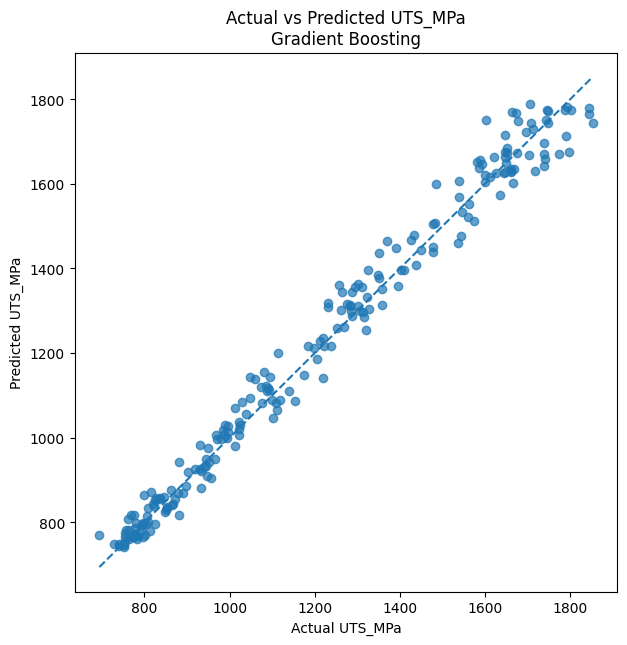

In [19]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.7
)

plt.xlabel(f"Actual {TARGET_COLUMN}")
plt.ylabel(f"Predicted {TARGET_COLUMN}")

plt.title(
    f"Actual vs Predicted {TARGET_COLUMN}\n{best_model_name}"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [20]:
residuals = y_test - y_pred_best

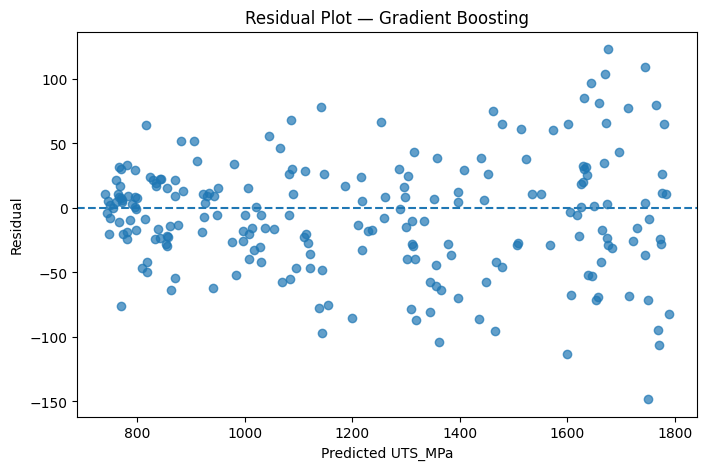

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(f"Predicted {TARGET_COLUMN}")
plt.ylabel("Residual")

plt.title(
    f"Residual Plot — {best_model_name}"
)

plt.show()

In [22]:
os.makedirs(RESULTS_PATH, exist_ok=True)

results_df.to_csv(
    os.path.join(RESULTS_PATH, f"baseline_{TARGET_COLUMN}_results.csv"),
    index=False
)

### Cross-validated comparison

A single train/test split can be noisy, so we confirm the ranking with 5-fold cross-validation over the full dataset.

In [23]:
cv_results = {}

for name, pipeline in pipelines.items():

    cv_results[name] = run_cross_validation(pipeline, X, y, cv)

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df

,MAE,MAE_STD,RMSE,RMSE_STD,R2,R2_STD
Linear Regression,60.793759,4.303631,78.073048,6.643520,0.946890,0.008687
Random Forest,33.209949,1.515565,43.424669,1.991744,0.983633,0.001498
Gradient Boosting,31.809014,1.552185,41.257725,2.430053,0.985195,0.001829


### Feature importance (Gradient Boosting)

In [24]:
# Extract the trained Gradient Boosting model
gb_pipeline = pipelines["Gradient Boosting"]

gb_model = gb_pipeline.named_steps["model"]
preprocessor_fitted = gb_pipeline.named_steps["preprocessor"]

In [25]:
feature_names = preprocessor_fitted.get_feature_names_out()

feature_names

array(['num__austenitizing_temp_C', 'num__section_thickness_mm',
       'num__tempering_temp_C', 'num__tempering_time_hr',
       'cat__quench_medium_air', 'cat__quench_medium_oil',
       'cat__quench_medium_water'], dtype=object)

In [26]:
importance = gb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
2,num__tempering_temp_C,0.962788
4,cat__quench_medium_air,0.029714
3,num__tempering_time_hr,0.005830
0,num__austenitizing_temp_C,0.001263
1,num__section_thickness_mm,0.000301
5,cat__quench_medium_oil,0.000063
6,cat__quench_medium_water,0.000040


In [27]:
feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance_df

,Feature,Importance
2,tempering_temp_C,0.962788
4,quench_medium_air,0.029714
3,tempering_time_hr,0.005830
0,austenitizing_temp_C,0.001263
1,section_thickness_mm,0.000301
5,quench_medium_oil,0.000063
6,quench_medium_water,0.000040


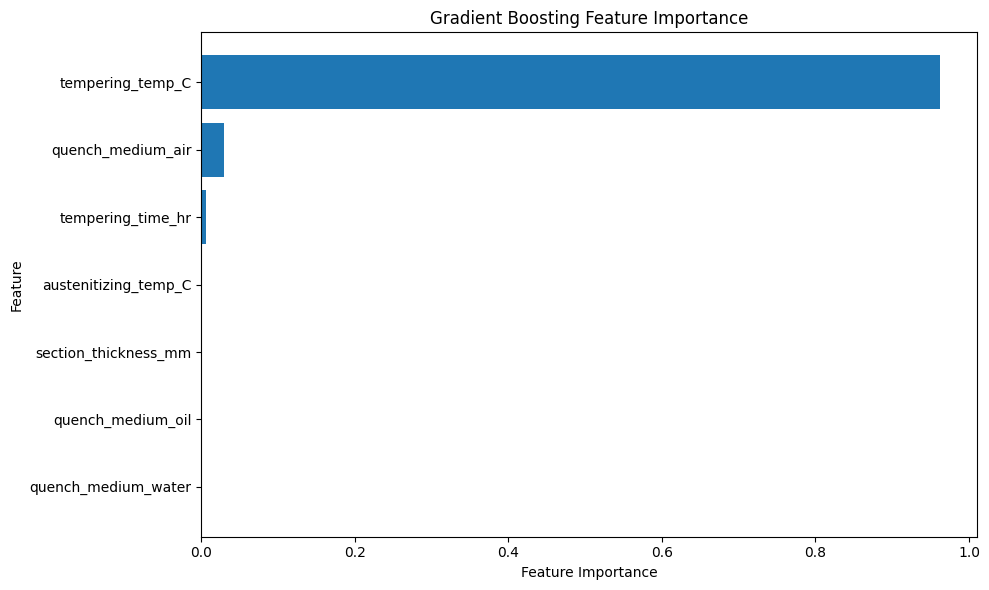

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Permutation importance

A model-agnostic cross-check on feature importance, computed directly on the held-out test set.

In [29]:
perm_result = permutation_importance(
    gb_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2"
)

perm_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

perm_importance_df = perm_importance_df.sort_values(
    by="Importance_Mean",
    ascending=False
)

perm_importance_df

,Feature,Importance_Mean,Importance_STD
3,tempering_temp_C,1.947127,0.144225
2,quench_medium,0.082488,0.020441
4,tempering_time_hr,0.013039,0.001261
1,section_thickness_mm,0.000088,0.000133
0,austenitizing_temp_C,-0.000251,0.000320


In [30]:
best_pipeline_hardness = pipelines[best_model_name]

os.makedirs(MODELS_PATH, exist_ok=True)

joblib.dump(
    best_pipeline_hardness,
    os.path.join(MODELS_PATH, f"best_baseline_{TARGET_COLUMN}_model.pkl")
)

['/content/drive/MyDrive/Heat_Treatment_Dashboard/models/best_baseline_UTS_MPa_model.pkl']

In [31]:
comparison = pd.DataFrame({
    f"Actual_{TARGET_COLUMN}": y_test.values,
    f"Predicted_{TARGET_COLUMN}": y_pred_best,
})

comparison["Error"] = (
    comparison[f"Actual_{TARGET_COLUMN}"]
    - comparison[f"Predicted_{TARGET_COLUMN}"]
)

comparison.head(10)

,Actual_UTS_MPa,Predicted_UTS_MPa,Error
0,1432.3,1478.493745,-46.193745
1,754.4,774.284450,-19.884450
2,755.6,766.232789,-10.632789
3,778.6,770.680538,7.919462
4,951.9,942.378000,9.522000
5,1646.8,1715.193389,-68.393389
6,848.6,824.593182,24.006818
7,1477.3,1506.145043,-28.845043
8,947.2,910.549357,36.650643
9,1012.0,1069.225027,-57.225027


In [32]:
comparison["Absolute_Error"] = (
    comparison["Error"].abs()
)

comparison.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

,Actual_UTS_MPa,Predicted_UTS_MPa,Error,Absolute_Error
29,1601.6,1749.761001,-148.161001,148.161001
60,1797.4,1674.384511,123.015489,123.015489
209,1485.3,1598.540992,-113.240992,113.240992
67,1852.3,1743.409189,108.890811,108.890811
132,1664.3,1770.732548,-106.432548,106.432548
83,1774.6,1670.597576,104.002424,104.002424
170,1256.7,1360.680255,-103.980255,103.980255
99,1047.1,1144.441621,-97.341621,97.341621
148,1739.4,1642.915121,96.484879,96.484879
47,1368.9,1464.428384,-95.528384,95.528384


## Feature Engineering

Before engineering anything, a quick sanity check on the categorical feature and on missing values.

In [33]:
print(X["quench_medium"].value_counts())

quench_medium
oil      770
water    210
air      120
Name: count, dtype: int64


In [34]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
austenitizing_temp_C    0
section_thickness_mm    0
quench_medium           0
tempering_temp_C        0
tempering_time_hr       0
dtype: int64

Missing values in y:
0


### Correlation before engineering

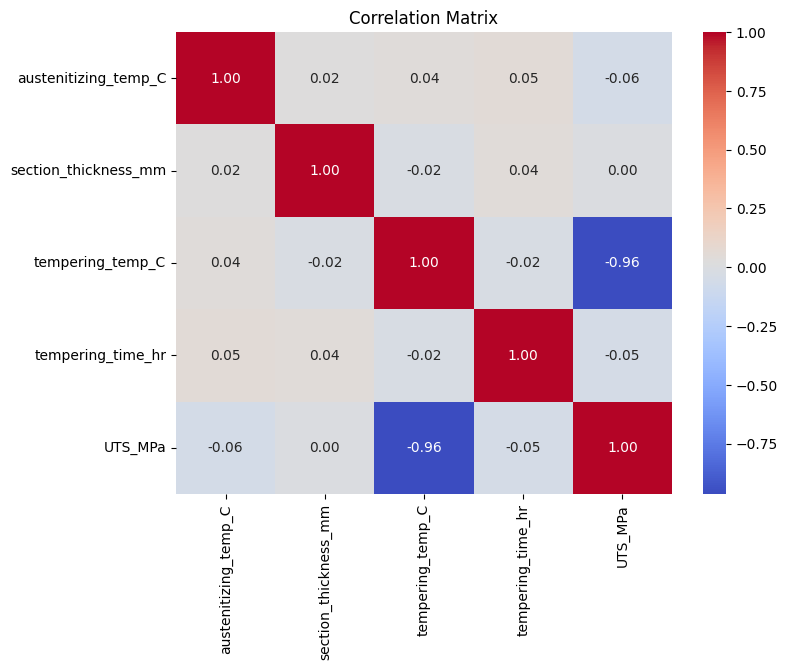

In [35]:
correlation_data = df[
    NUMERICAL_FEATURES + [TARGET_COLUMN]
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Candidate engineered features

Two candidates are tested:

- **`tempering_temp_time`** — a simple interaction of tempering temperature and time.
- **`tempering_parameter`** — the Hollomon-Jaffe tempering parameter,
  `(T + 273.15) * (C + log10(t))`, a metallurgical relationship known to
  capture the combined effect of tempering temperature and time on hardness.

Both are produced by the shared `add_engineered_features` helper defined in Setup.

In [36]:
X_engineered = add_engineered_features(X)

X_engineered[
    [
        "tempering_temp_C",
        "tempering_time_hr",
        "tempering_temp_time",
        "tempering_parameter"
    ]
].head()

,tempering_temp_C,tempering_time_hr,tempering_temp_time,tempering_parameter
0,815.0,1.0,815.0,21763.000000
1,316.0,1.0,316.0,11783.000000
2,538.0,1.0,538.0,16223.000000
3,384.7,4.0,1538.8,13553.065165
4,401.7,4.0,1606.8,13903.300185


In [37]:
X_engineered[
    [
        "tempering_temp_C",
        "tempering_time_hr",
        "tempering_temp_time",
        "tempering_parameter"
    ]
].describe()

,tempering_temp_C,tempering_time_hr,tempering_temp_time,tempering_parameter
count,1100.000000,1100.00000,1100.000000,1100.000000
mean,418.995182,1.81500,756.266091,13935.918170
std,134.022222,1.32076,623.933457,2704.165707
min,202.500000,0.50000,101.850000,9393.453847
25%,295.300000,0.50000,277.975000,11475.157205
50%,414.950000,1.00000,530.300000,13904.939184
75%,533.025000,2.00000,1066.400000,16223.514161
max,815.000000,4.00000,2625.600000,21763.000000


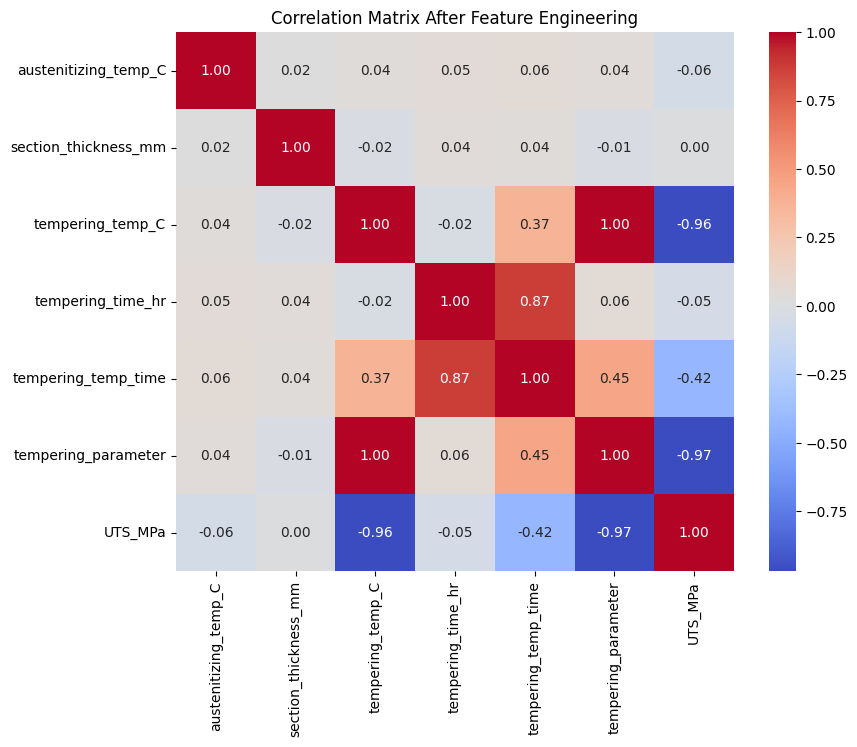

In [38]:
corr = pd.concat(
    [
        X_engineered.drop(columns=["quench_medium"]),
        y
    ],
    axis=1
).corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix After Feature Engineering")
plt.show()

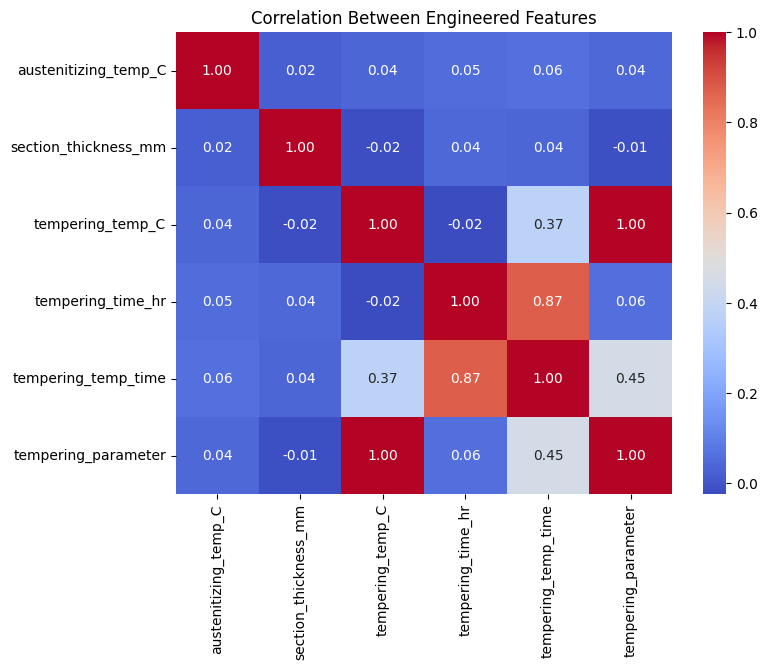

In [39]:
feature_corr = X_engineered.drop(
    columns=["quench_medium"]
).corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    feature_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Engineered Features")
plt.show()

### Building feature sets for experimentation

We build four candidate feature sets on a full copy of the dataframe (so the target column is available for later use) using the same `add_engineered_features` helper — no formula is duplicated.

In [40]:
df_fe = add_engineered_features(df, C=20)

df_fe[
    [
        "tempering_temp_C",
        "tempering_time_hr",
        "tempering_temp_time",
        "tempering_parameter"
    ]
].head()

,tempering_temp_C,tempering_time_hr,tempering_temp_time,tempering_parameter
0,815.0,1.0,815.0,21763.000000
1,316.0,1.0,316.0,11783.000000
2,538.0,1.0,538.0,16223.000000
3,384.7,4.0,1538.8,13553.065165
4,401.7,4.0,1606.8,13903.300185


In [41]:
# Original + Temperature x Time
temp_time_features = BASE_FEATURE_COLUMNS + [
    "tempering_temp_time"
]

# Original + Hollomon-Jaffe tempering parameter
tempering_parameter_features = BASE_FEATURE_COLUMNS + [
    "tempering_parameter"
]

# Original + both engineered features
both_engineered_features = BASE_FEATURE_COLUMNS + [
    "tempering_temp_time",
    "tempering_parameter"
]

In [42]:
X_original = df_fe[BASE_FEATURE_COLUMNS].copy()

X_temp_time = df_fe[temp_time_features].copy()

X_tempering_parameter = df_fe[tempering_parameter_features].copy()

X_both = df_fe[both_engineered_features].copy()

y = df_fe[TARGET_COLUMN].copy()

In [43]:
print("Original:", X_original.shape)
print("Temp x Time:", X_temp_time.shape)
print("Tempering Parameter:", X_tempering_parameter.shape)
print("Both:", X_both.shape)

Original: (1100, 5)
Temp x Time: (1100, 6)
Tempering Parameter: (1100, 6)
Both: (1100, 7)


### Comparing feature sets with a single train/test split

`evaluate_gradient_boosting` builds a fresh preprocessor + Gradient Boosting pipeline for whichever feature set it's given (numerical vs. categorical columns are auto-detected by dtype), trains it, and scores it — reusing the shared `build_preprocessor` and `evaluate_predictions` helpers instead of repeating that logic per experiment.

In [44]:
def evaluate_gradient_boosting(X, y, feature_set_name):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    numerical_features = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    preprocessor = build_preprocessor(numerical_features, categorical_features)

    model = GradientBoostingRegressor(random_state=RANDOM_STATE)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae, rmse, r2 = evaluate_predictions(y_test, y_pred)

    return {
        "Feature Set": feature_set_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pipeline": pipeline
    }

#### Experiment A — Original features only

In [45]:
result_original = evaluate_gradient_boosting(
    X_original,
    y,
    "Original Features"
)

#### Experiment B — + Temperature × Time interaction

In [46]:
result_temp_time = evaluate_gradient_boosting(
    X_temp_time,
    y,
    "Original + Temperature x Time"
)

#### Experiment C — + Hollomon-Jaffe tempering parameter

In [47]:
result_tempering_parameter = evaluate_gradient_boosting(
    X_tempering_parameter,
    y,
    "Original + Tempering Parameter"
)

#### Experiment D — + Both engineered features

In [48]:
result_both = evaluate_gradient_boosting(
    X_both,
    y,
    "Original + Both Engineered Features"
)

In [49]:
results = [
    result_original,
    result_temp_time,
    result_tempering_parameter,
    result_both
]

comparison = pd.DataFrame(results)

comparison_table = comparison[
    [
        "Feature Set",
        "MAE",
        "RMSE",
        "R2"
    ]
].copy()

comparison_table = comparison_table.sort_values(
    by="R2",
    ascending=False
)

comparison_table

,Feature Set,MAE,RMSE,R2
2,Original + Tempering Parameter,33.285521,43.433753,0.984011
3,Original + Both Engineered Features,33.969169,44.297980,0.983369
1,Original + Temperature x Time,34.566963,44.607849,0.983135
0,Original Features,34.504017,44.638355,0.983112


In [50]:
os.makedirs(RESULTS_PATH, exist_ok=True)

comparison_table.to_csv(
    os.path.join(RESULTS_PATH, f"Feature_Engg_{TARGET_COLUMN}_results.csv"),
    index=False
)

### Confirming with 5-fold cross-validation

Same idea as `evaluate_gradient_boosting`, but scored with `run_cross_validation` instead of a single split, for a more robust comparison.

In [51]:
def evaluate_cv(X, y, feature_set_name):

    numerical_features = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    preprocessor = build_preprocessor(numerical_features, categorical_features)

    model = GradientBoostingRegressor(random_state=RANDOM_STATE)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    cv_scores = run_cross_validation(pipeline, X, y, cv)

    return {
        "Feature Set": feature_set_name,
        "CV MAE": cv_scores["MAE"],
        "CV RMSE": cv_scores["RMSE"],
        "CV R2": cv_scores["R2"],
        "MAE STD": cv_scores["MAE_STD"],
        "RMSE STD": cv_scores["RMSE_STD"],
        "R2 STD": cv_scores["R2_STD"]
    }

In [52]:
cv_original = evaluate_cv(
    X_original,
    y,
    "Original Features"
)

cv_temp_time = evaluate_cv(
    X_temp_time,
    y,
    "Original + Temperature x Time"
)

cv_tempering_parameter = evaluate_cv(
    X_tempering_parameter,
    y,
    "Original + Tempering Parameter"
)

cv_both = evaluate_cv(
    X_both,
    y,
    "Original + Both Engineered Features"
)

In [53]:
cv_results = [
    cv_original,
    cv_temp_time,
    cv_tempering_parameter,
    cv_both
]

cv_comparison = pd.DataFrame(cv_results)

cv_comparison = cv_comparison.sort_values(
    by="CV R2",
    ascending=False
)

cv_comparison

,Feature Set,CV MAE,CV RMSE,CV R2,MAE STD,RMSE STD,R2 STD
2,Original + Tempering Parameter,31.462200,40.995276,0.985422,1.124574,1.585858,0.001149
3,Original + Both Engineered Features,31.622576,41.245281,0.985235,1.257874,1.842343,0.001351
0,Original Features,31.809014,41.257725,0.985195,1.552185,2.430053,0.001829
1,Original + Temperature x Time,31.645166,41.324524,0.985151,1.662397,2.473991,0.001795


In [54]:
os.makedirs(RESULTS_PATH, exist_ok=True)

cv_comparison.to_csv(
    os.path.join(RESULTS_PATH, f"Feature_Engg_CV_{TARGET_COLUMN}_results.csv"),
    index=False
)

### Selecting the winning feature set

The Hollomon-Jaffe `tempering_parameter` feature wins (or ties) across both evaluations, so it's the one carried forward.

In [55]:
final_features = BASE_FEATURE_COLUMNS + ["tempering_parameter"]

X_final = df_fe[final_features].copy()

y = df_fe[TARGET_COLUMN].copy()

In [56]:
X_final.head()

,austenitizing_temp_C,section_thickness_mm,quench_medium,tempering_temp_C,tempering_time_hr,tempering_parameter
0,845.0,25.0,oil,815.0,1.0,21763.000000
1,845.0,25.0,oil,316.0,1.0,11783.000000
2,845.0,25.0,oil,538.0,1.0,16223.000000
3,851.7,50.0,oil,384.7,4.0,13553.065165
4,834.4,100.0,air,401.7,4.0,13903.300185


In [57]:
X_final.shape

(1100, 6)

## Model Evaluation with Feature Engineering

With `tempering_parameter` selected, we re-run the full model comparison — now including a Neural Network — with the engineered feature included, scored via cross-validation.

In [58]:
# Work on a copy so the original df is never mutated in place
df_model = df.copy()

df_model["tempering_parameter"] = (
    (df_model["tempering_temp_C"] + 273.15)
    * (20 + np.log10(df_model["tempering_time_hr"]))
)

X = df_model[final_features].copy()
y = df_model[TARGET_COLUMN].copy()

In [59]:
final_numerical_features = NUMERICAL_FEATURES + ["tempering_parameter"]
final_categorical_features = CATEGORICAL_FEATURES

preprocessor = build_preprocessor(final_numerical_features, final_categorical_features)

In [60]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),

    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(32, 16, 8),
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    )
}

In [61]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [62]:
results = []

for name, pipeline in pipelines.items():

    cv_scores = run_cross_validation(pipeline, X, y, cv)

    results.append({
        "Model": name,
        "CV MAE": cv_scores["MAE"],
        "CV MAE STD": cv_scores["MAE_STD"],
        "CV RMSE": cv_scores["RMSE"],
        "CV RMSE STD": cv_scores["RMSE_STD"],
        "CV R2": cv_scores["R2"],
        "CV R2 STD": cv_scores["R2_STD"]
    })

results_df = pd.DataFrame(results)

In [63]:
results_df = results_df.sort_values(
    by="CV MAE"
).reset_index(drop=True)

results_df

,Model,CV MAE,CV MAE STD,CV RMSE,CV RMSE STD,CV R2,CV R2 STD
0,Gradient Boosting,31.462200,1.124574,40.995276,1.585858,0.985422,0.001149
1,Random Forest,32.668370,0.876566,42.807492,1.531045,0.984109,0.001139
2,Neural Network,58.526115,3.154760,78.789892,2.477095,0.946214,0.002890
3,Linear Regression,60.552517,3.981691,77.665325,6.361590,0.947466,0.008276


In [64]:
os.makedirs(RESULTS_PATH, exist_ok=True)

results_df.to_csv(
    os.path.join(RESULTS_PATH, f"Model_Eval_{TARGET_COLUMN}_results.csv"),
    index=False
)

## Hyperparameter Tuning

Gradient Boosting is the strongest, most consistent performer, so it's the one we tune. A fresh train/test split and an untuned baseline pipeline are created first so the tuned model has something concrete to be compared against.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(final_numerical_features, final_categorical_features)),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

baseline_pipeline.fit(X_train, y_train)

y_pred_baseline = baseline_pipeline.predict(X_test)

baseline_mae, baseline_rmse, baseline_r2 = evaluate_predictions(y_test, y_pred_baseline)

print("Baseline Gradient Boosting")
print("---------------------------")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Gradient Boosting
---------------------------
MAE  : 33.2855
RMSE : 43.4338
R²   : 0.9840


In [66]:
param_distributions = {
    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.15
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__subsample": [
        0.8,
        0.9,
        1.0
    ]
}

In [67]:
search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['austenitizing_temp_C',
                                                                                'section_thickness_mm',
                                                                                'tempering_temp_C',
                                                                                'tempering_time_hr',
                                                                                'tempering_parameter']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('onehot',
                                                                                                OneHotEncod...
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1,
                                                                 0.15],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [68]:
print("Best Parameters:")
print(search.best_params_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 4, 'model__learning_rate': 0.05}


In [69]:
best_cv_mae = -search.best_score_

print(
    f"Best CV MAE: {best_cv_mae:.4f}"
)

Best CV MAE: 30.4451


In [70]:
best_model = search.best_estimator_

In [71]:
y_pred_tuned = best_model.predict(
    X_test
)

tuned_mae, tuned_rmse, tuned_r2 = evaluate_predictions(y_test, y_pred_tuned)

print("Tuned Gradient Boosting")
print("-----------------------")
print(f"MAE  : {tuned_mae:.4f}")
print(f"RMSE : {tuned_rmse:.4f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned Gradient Boosting
-----------------------
MAE  : 33.2276
RMSE : 43.4554
R²   : 0.9840


In [72]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "MAE": [
        baseline_mae,
        tuned_mae
    ],

    "RMSE": [
        baseline_rmse,
        tuned_rmse
    ],

    "R2": [
        baseline_r2,
        tuned_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline Gradient Boosting,33.285521,43.433753,0.984011
1,Tuned Gradient Boosting,33.227598,43.455434,0.983995


In [73]:
os.makedirs(RESULTS_PATH, exist_ok=True)

comparison.to_csv(
    os.path.join(RESULTS_PATH, f"Hyperparameter_Tuning_{TARGET_COLUMN}_results.csv"),
    index=False
)

In [74]:
baseline_cv = run_cross_validation(baseline_pipeline, X_train, y_train, cv)
tuned_cv = run_cross_validation(best_model, X_train, y_train, cv)

print("Baseline CV")
print("MAE :", baseline_cv["MAE"])
print("RMSE:", baseline_cv["RMSE"])
print("R2  :", baseline_cv["R2"])

print("\nTuned CV")
print("MAE :", tuned_cv["MAE"])
print("RMSE:", tuned_cv["RMSE"])
print("R2  :", tuned_cv["R2"])

Baseline CV
MAE : 31.084914932278032
RMSE: 40.634195664716465
R2  : 0.9855828201326015

Tuned CV
MAE : 30.44511014724211
RMSE: 39.69409113175434
R2  : 0.9862314467446135


## Final Model

The engineered `tempering_parameter` feature is wrapped in a proper `TransformerMixin` so it becomes part of the pipeline itself, rather than a manual step the caller has to remember to run. That makes the saved pipeline self-contained: it accepts the five raw input columns and does everything else internally.

In [75]:
import sys
import importlib.util

PROJECT_DIR = "/content/drive/MyDrive/Heat_Treatment_Dashboard/PowerBI"
FILE_PATH = f"{PROJECT_DIR}/tempering_transformers.py"

spec = importlib.util.spec_from_file_location(
    "tempering_transformers",
    FILE_PATH
)

tempering_transformers = importlib.util.module_from_spec(spec)

sys.modules["tempering_transformers"] = tempering_transformers

spec.loader.exec_module(tempering_transformers)

TemperingParameterTransformer = (
    tempering_transformers.TemperingParameterTransformer
)

YSTemperingParameterTransformer = (
    tempering_transformers.YSTemperingParameterTransformer
)

print("SUCCESS")
print(TemperingParameterTransformer)
print(YSTemperingParameterTransformer)

SUCCESS
<class 'tempering_transformers.TemperingParameterTransformer'>
<class 'tempering_transformers.YSTemperingParameterTransformer'>


In [76]:
input_features = BASE_FEATURE_COLUMNS

X = df[input_features].copy()
y = df[TARGET_COLUMN].copy()

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 880
Testing samples : 220


In [78]:
numerical_features = NUMERICAL_FEATURES + ["tempering_parameter"]
categorical_features = CATEGORICAL_FEATURES

preprocessor = build_preprocessor(numerical_features, categorical_features)

In [79]:
final_model = GradientBoostingRegressor(
    random_state=RANDOM_STATE
)
# To ship the tuned hyperparameters instead, replace the line above with:
# final_model = GradientBoostingRegressor(random_state=RANDOM_STATE, **{
#     k.replace("model__", ""): v for k, v in search.best_params_.items()
# })

In [80]:
final_pipeline = Pipeline(
    steps=[
        (
            "tempering_parameter",
            TemperingParameterTransformer(C=20)
        ),
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            final_model
        )
    ]
)

In [81]:
final_pipeline.fit(
    X_train,
    y_train
)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [82]:
y_pred = final_pipeline.predict(X_test)

In [83]:
mae, rmse, r2 = evaluate_predictions(y_test, y_pred)

print("Final Model Performance")
print("-----------------------")
print(f"MAE  : {mae:.4f} ({TARGET_COLUMN})")
print(f"RMSE : {rmse:.4f} ({TARGET_COLUMN})")
print(f"R²   : {r2:.6f}")

Final Model Performance
-----------------------
MAE  : 33.2855 (UTS_MPa)
RMSE : 43.4338 (UTS_MPa)
R²   : 0.984011


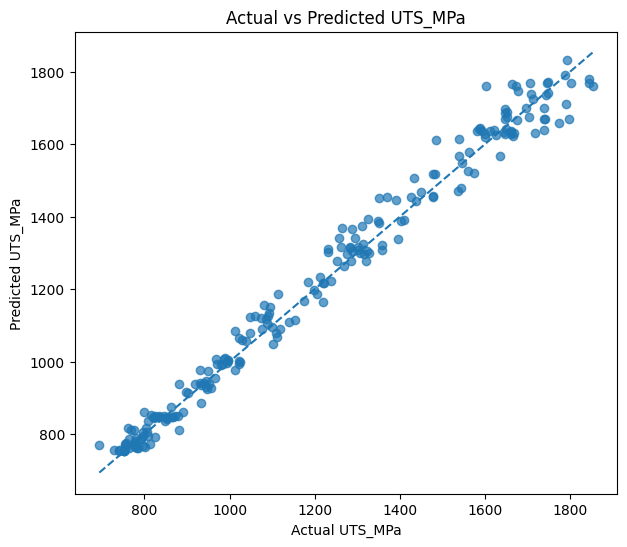

In [84]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel(f"Actual {TARGET_COLUMN}")
plt.ylabel(f"Predicted {TARGET_COLUMN}")
plt.title(f"Actual vs Predicted {TARGET_COLUMN}")

plt.show()

In [85]:
residuals = y_test - y_pred

print("Mean Residual:", residuals.mean())
print("Residual Std :", residuals.std())

Mean Residual: -6.932755429097882
Residual Std : 42.974672028633734


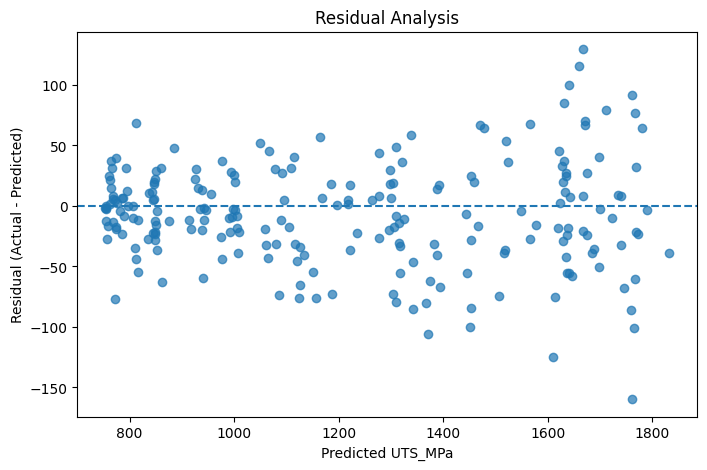

In [86]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(f"Predicted {TARGET_COLUMN}")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis")

plt.show()

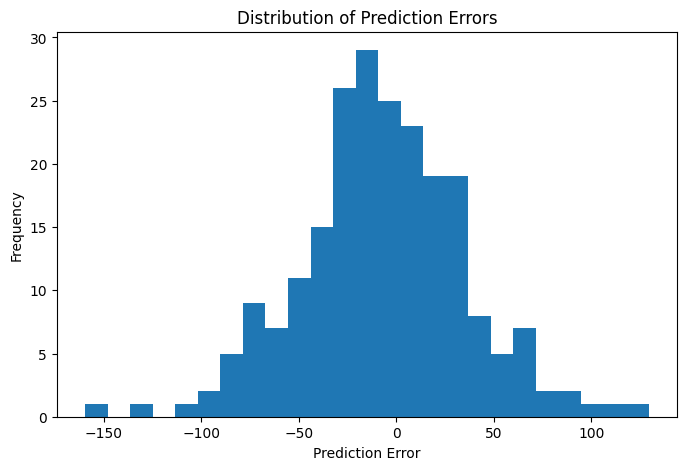

In [87]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=25
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

In [88]:
comparison = pd.DataFrame({
    f"Actual_{TARGET_COLUMN}": y_test.values,
    f"Predicted_{TARGET_COLUMN}": y_pred,
    "Residual": residuals.values
})

comparison.head(10)

,Actual_UTS_MPa,Predicted_UTS_MPa,Residual
0,1432.3,1506.987475,-74.687475
1,754.4,773.838967,-19.438967
2,755.6,768.563993,-12.963993
3,778.6,763.917392,14.682608
4,951.9,938.674432,13.225568
5,1646.8,1697.325589,-50.525589
6,848.6,837.687918,10.912082
7,1477.3,1516.224865,-38.924865
8,947.2,924.766782,22.433218
9,1012.0,1085.322106,-73.322106


In [89]:
absolute_errors = np.abs(
    y_test.values - y_pred
)

print(
    "Maximum Absolute Error:",
    absolute_errors.max()
)

# Mean absolute error is already available as `mae`, computed above
print(
    "Mean Absolute Error:",
    mae
)

Maximum Absolute Error: 159.64508154017972
Mean Absolute Error: 33.28552102738578


In [90]:
model_filename = f"aisi4140_{TARGET_COLUMN}_pipeline.pkl"

os.makedirs(MODELS_PATH, exist_ok=True)

model_path = os.path.join(MODELS_PATH, model_filename)

joblib.dump(
    final_pipeline,
    model_path
)

print(f"Pipeline saved successfully at: {model_path}")

Pipeline saved successfully at: /content/drive/MyDrive/Heat_Treatment_Dashboard/models/aisi4140_UTS_MPa_pipeline.pkl


In [91]:
print(
    "File exists:",
    os.path.exists(model_path)
)

print(
    "File size:",
    os.path.getsize(model_path) / 1024,
    "KB"
)

File exists: True
File size: 137.9814453125 KB


In [92]:
loaded_pipeline = joblib.load(
    model_path
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [93]:
new_condition = pd.DataFrame({
    "austenitizing_temp_C": [880],
    "section_thickness_mm": [20],
    "quench_medium": ["oil"],
    "tempering_temp_C": [550],
    "tempering_time_hr": [2]
})

new_condition

,austenitizing_temp_C,section_thickness_mm,quench_medium,tempering_temp_C,tempering_time_hr
0,880,20,oil,550,2


In [94]:
predicted_value = loaded_pipeline.predict(
    new_condition
)

print(
    f"Predicted {TARGET_COLUMN}: {predicted_value[0]:.2f}"
)


Predicted UTS_MPa: 851.23


In [95]:
candidate_conditions = pd.DataFrame({
    "austenitizing_temp_C": [850, 850, 850, 860, 860],
    "section_thickness_mm": [20, 20, 20, 20, 20],
    "quench_medium": ["air", "oil", "water", "oil", "water"],
    "tempering_temp_C": [450, 500, 550, 500, 550],
    "tempering_time_hr": [2, 2, 2, 2, 2]
})

candidate_conditions

,austenitizing_temp_C,section_thickness_mm,quench_medium,tempering_temp_C,tempering_time_hr
0,850,20,air,450,2
1,850,20,oil,500,2
2,850,20,water,550,2
3,860,20,oil,500,2
4,860,20,water,550,2


In [96]:
candidate_predictions = loaded_pipeline.predict(
    candidate_conditions
)

candidate_conditions[f"Predicted_{TARGET_COLUMN}"] = (
    candidate_predictions
)

candidate_conditions

,austenitizing_temp_C,section_thickness_mm,quench_medium,tempering_temp_C,tempering_time_hr,Predicted_UTS_MPa
0,850,20,air,450,2,1078.654248
1,850,20,oil,500,2,950.572410
2,850,20,water,550,2,847.505403
3,860,20,oil,500,2,950.992085
4,860,20,water,550,2,847.925078


In [97]:
candidate_conditions.to_csv(
    f"sample_{TARGET_COLUMN}_predictions.csv",
    index=False
)



os.makedirs(RESULTS_PATH, exist_ok=True)

candidate_conditions.to_csv(
    os.path.join(RESULTS_PATH, f"sample_{TARGET_COLUMN}_predictions.csv"),
    index=False
)

print("Prediction file saved.")

Prediction file saved.


In [98]:
print("FINAL MODEL SUMMARY")
print("===================")

print("\nTarget:")
print(TARGET_COLUMN)

print("\nModel:")
print("GradientBoostingRegressor")

print("\nFeatures:")
for feature in input_features:
    print("-", feature)

print("\nEngineered Feature:")
print("- tempering_parameter")

print("\nTest Performance:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.6f}")

print("\nSaved Model:")
print(model_filename)

FINAL MODEL SUMMARY

Target:
UTS_MPa

Model:
GradientBoostingRegressor

Features:
- austenitizing_temp_C
- section_thickness_mm
- quench_medium
- tempering_temp_C
- tempering_time_hr

Engineered Feature:
- tempering_parameter

Test Performance:
MAE  : 33.2855
RMSE : 43.4338
R²   : 0.984011

Saved Model:
aisi4140_UTS_MPa_pipeline.pkl
